# Multi-Head Attention — from scratch

Implementing the core mechanism of the Transformer, from the raw formula to a full PyTorch module.

The roadmap:
1. Single-head attention in NumPy — understand the math
2. Visualize the attention matrix — what does the model actually look at?
3. Multi-head attention — split, attend, concatenate
4. Rewrite it as a `nn.Module` in PyTorch
5. Verify against `nn.MultiheadAttention` (diff < 1e-4)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

np.random.seed(42)
torch.manual_seed(42)

print(f"numpy  {np.__version__}")
print(f"torch  {torch.__version__}")

numpy  2.5.0
torch  2.12.1+cpu


## 1. Scaled dot-product attention (NumPy)

The full formula from *Attention Is All You Need*:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

Breaking it down:
- **Q** (Query) — what this token is looking for
- **K** (Key)   — what each token has to offer
- **V** (Value) — the actual content to retrieve
- **QKᵀ**       — dot product = similarity score between every pair of tokens
- **/ √d_k**    — scaling: without it, scores blow up when d_k is large → softmax saturates → gradients vanish
- **softmax**   — turns raw scores into a probability distribution (sums to 1 per row)
- **× V**       — weighted sum of values according to those probabilities

The output for each token is a blend of all values, weighted by how much that token attended to each other token.

In [2]:
def softmax(x, axis=-1):
    """Numerically stable softmax."""
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    """
    Q, K, V: (seq_len, d_k)
    Returns: output (seq_len, d_k), attention_weights (seq_len, seq_len)
    """
    d_k = Q.shape[-1]
    scores  = Q @ K.T / np.sqrt(d_k)   # (seq_len, seq_len)
    weights = softmax(scores)            # each row sums to 1
    output  = weights @ V               # (seq_len, d_k)
    return output, weights

# Quick sanity check on toy data
seq_len, d_k = 4, 8
Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_k)

output, weights = scaled_dot_product_attention(Q, K, V)

print(f"output shape  : {output.shape}")
print(f"weights shape : {weights.shape}")
print(f"rows sum to 1 : {np.allclose(weights.sum(axis=-1), 1.0)}")
print(f"weights in [0,1]: {weights.min() >= 0 and weights.max() <= 1}")

output shape  : (4, 8)
weights shape : (4, 4)
rows sum to 1 : True
weights in [0,1]: True


## 2. Visualizing the attention matrix

The attention matrix tells you which tokens "look at" which other tokens. Row `i`, column `j` = how much token `i` attends to token `j`.

I'll build a small example with 5 words from a sentence to make the visualization meaningful.

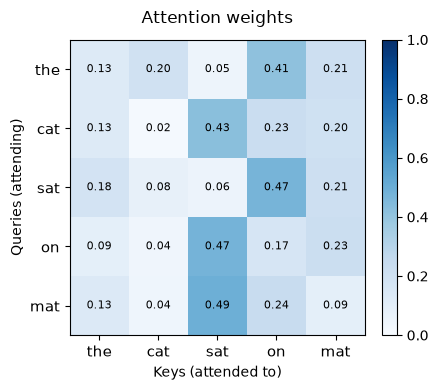

Saved: attention_heatmap.png


In [3]:
tokens = ["the", "cat", "sat", "on", "mat"]
seq_len = len(tokens)
d_k = 16

# Random projections — in a real transformer these are learned weight matrices
Q_vis = np.random.randn(seq_len, d_k)
K_vis = np.random.randn(seq_len, d_k)
V_vis = np.random.randn(seq_len, d_k)

_, attn_weights = scaled_dot_product_attention(Q_vis, K_vis, V_vis)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(attn_weights, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
ax.set_xticklabels(tokens, fontsize=11)
ax.set_yticklabels(tokens, fontsize=11)
ax.set_xlabel("Keys (attended to)", fontsize=10)
ax.set_ylabel("Queries (attending)", fontsize=10)
ax.set_title("Attention weights", fontsize=12, pad=12)

for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, f"{attn_weights[i, j]:.2f}",
                ha='center', va='center', fontsize=8,
                color='white' if attn_weights[i, j] > 0.5 else 'black')

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("attention_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: attention_heatmap.png")

With random Q/K/V the weights are roughly uniform — no token has a reason to focus on any specific other token. In a trained model, "mat" would likely attend strongly to "the" (its article) and "sat" would attend to "cat" (its subject). That pattern emerges during training, not from the architecture itself.

## 3. Multi-Head Attention (NumPy)

Instead of running one big attention with dimension `d_model`, we run `h` smaller attentions in parallel, each with dimension `d_k = d_model / h`.

Why? Each head can specialize in a different type of relationship — one head might track grammatical structure, another semantic similarity. The results are concatenated and projected back to `d_model`.

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) \, W^O$$
$$\text{where head}_i = \text{Attention}(QW_i^Q,\; KW_i^K,\; VW_i^V)$$

In [4]:
def multi_head_attention_numpy(Q, K, V, W_Q, W_K, W_V, W_O, num_heads):
    """
    Q, K, V : (seq_len, d_model)
    W_Q, W_K, W_V : (d_model, d_model)
    W_O : (d_model, d_model)
    Returns: output (seq_len, d_model)
    """
    seq_len, d_model = Q.shape
    d_k = d_model // num_heads

    # Project into d_model space
    Q_proj = Q @ W_Q   # (seq_len, d_model)
    K_proj = K @ W_K
    V_proj = V @ W_V

    # Split into heads and run attention on each
    head_outputs = []
    for h in range(num_heads):
        q_h = Q_proj[:, h * d_k : (h + 1) * d_k]   # (seq_len, d_k)
        k_h = K_proj[:, h * d_k : (h + 1) * d_k]
        v_h = V_proj[:, h * d_k : (h + 1) * d_k]
        out_h, _ = scaled_dot_product_attention(q_h, k_h, v_h)
        head_outputs.append(out_h)

    # Concatenate all heads and project
    concat = np.concatenate(head_outputs, axis=-1)   # (seq_len, d_model)
    output = concat @ W_O
    return output

# Test
seq_len, d_model, num_heads = 5, 16, 4

Q = np.random.randn(seq_len, d_model)
K = np.random.randn(seq_len, d_model)
V = np.random.randn(seq_len, d_model)
W_Q = np.random.randn(d_model, d_model)
W_K = np.random.randn(d_model, d_model)
W_V = np.random.randn(d_model, d_model)
W_O = np.random.randn(d_model, d_model)

out = multi_head_attention_numpy(Q, K, V, W_Q, W_K, W_V, W_O, num_heads)
print(f"Input  shape: {Q.shape}")
print(f"Output shape: {out.shape}  (same — attention doesn't change the shape)")

Input  shape: (5, 16)
Output shape: (5, 16)  (same — attention doesn't change the shape)


## 4. `MultiHeadAttention` as a `nn.Module` (PyTorch)

Same logic, but now using PyTorch — which means the weight matrices are `nn.Linear` layers (learnable), and we can use batched tensors `(batch, seq_len, d_model)` instead of `(seq_len, d_model)`.

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Linear projections (bias=False to match nn.MultiheadAttention in_proj convention)
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, Q, K, V):
        """
        Q, K, V: (batch, seq_len, d_model)
        Returns: output (batch, seq_len, d_model), weights (batch, num_heads, seq_len, seq_len)
        """
        B, T, _ = Q.shape

        # Project and reshape to (B, num_heads, T, d_k)
        q = self.W_Q(Q).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        k = self.W_K(K).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        v = self.W_V(V).view(B, T, self.num_heads, self.d_k).transpose(1, 2)

        # Scaled dot-product attention on all heads at once
        scores  = q @ k.transpose(-2, -1) / (self.d_k ** 0.5)   # (B, h, T, T)
        weights = F.softmax(scores, dim=-1)
        attn    = weights @ v                                      # (B, h, T, d_k)

        # Merge heads and project
        out = attn.transpose(1, 2).contiguous().view(B, T, -1)    # (B, T, d_model)
        return self.W_O(out), weights

# Sanity check
d_model, num_heads, seq_len, batch = 32, 4, 6, 2

mha = MultiHeadAttention(d_model, num_heads)
x   = torch.randn(batch, seq_len, d_model)

out, weights = mha(x, x, x)   # self-attention: Q = K = V = x

print(f"Input  : {x.shape}")
print(f"Output : {out.shape}")
print(f"Weights: {weights.shape}  (batch, heads, seq, seq)")
print(f"Rows sum to 1: {torch.allclose(weights.sum(-1), torch.ones_like(weights.sum(-1)))}")

Input  : torch.Size([2, 6, 32])
Output : torch.Size([2, 6, 32])
Weights: torch.Size([2, 4, 6, 6])  (batch, heads, seq, seq)
Rows sum to 1: True


## 5. Verification against `nn.MultiheadAttention`

PyTorch ships its own implementation. If mine is correct, the outputs should match up to floating-point precision when using the same weights.

In [6]:
d_model, num_heads, seq_len, batch = 32, 4, 6, 2
torch.manual_seed(0)

x = torch.randn(batch, seq_len, d_model)

# --- My implementation ---
my_mha = MultiHeadAttention(d_model, num_heads)

# --- PyTorch built-in (batch_first=True so shapes match) ---
pt_mha = nn.MultiheadAttention(d_model, num_heads, bias=False, batch_first=True)

# Copy my weights into PyTorch's module
# nn.MultiheadAttention stores Q/K/V as a single concatenated in_proj_weight
with torch.no_grad():
    pt_mha.in_proj_weight.copy_(torch.cat([
        my_mha.W_Q.weight,
        my_mha.W_K.weight,
        my_mha.W_V.weight,
    ], dim=0))
    pt_mha.out_proj.weight.copy_(my_mha.W_O.weight)

# Forward pass
my_out, _  = my_mha(x, x, x)
pt_out, _  = pt_mha(x, x, x)

max_diff = (my_out - pt_out).abs().max().item()
print(f"Max difference : {max_diff:.2e}")
print(f"Match (< 1e-4) : {max_diff < 1e-4}")

Max difference : 9.13e-08
Match (< 1e-4) : True
